In [ ]:
from google.colab import drive
drive.mount('/gdrive/')

Drive already mounted at /gdrive/; to attempt to forcibly remount, call drive.mount("/gdrive/", force_remount=True).


In [ ]:
# ID do arquivo do Google Drive
file_id = '1vTvM-jwd_ot0hTqoKjKZj7zOig_k_FWy'
# Nome do arquivo para salvar no Colab
file_name = 'no_nan_categorization_estado_amazonas.json'
# Baixa o arquivo do Google Drive
!gdown --id {file_id} -O {file_name}

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1on9ElLJVW5dLWuURkjFGIt1eQS8ZSUTs
To: /content/no_nan_categorization_estado_amazonas.json
100% 75.3k/75.3k [00:00<00:00, 47.1MB/s]


In [ ]:
import json
import matplotlib.pyplot as plt

# Caminho do arquivo JSON
json_path = file_name

# Carregar o arquivo JSON
with open(json_path, "r", encoding="utf-8") as f:
    legends = json.load(f)

print("Variáveis disponíveis no JSON:")
for i, col in enumerate(legends.keys(), 1):
    print(f"{i}. {col}")

# Input interativo (número ou nome da coluna)
selected = input("\nDigite os números OU nomes das variáveis (separados por vírgula): ").strip()
selected_items = [x.strip() for x in selected.split(",") if x.strip()]

# Converter entradas para nomes de colunas
selected_cols = []
for item in selected_items:
    if item.isdigit():
        idx = int(item)
        if 1 <= idx <= len(legends):
            selected_cols.append(list(legends.keys())[idx - 1])
    else:
        if item in legends:
            selected_cols.append(item)

# Criar gráficos
for col_name in selected_cols:
    legend = legends[col_name]

    categories, freqs = [], []
    for cat, val in legend.items():
        # Extract frequency from the nested dictionary
        freq = 0
        if isinstance(val, dict) and 'frequency' in val:
            try:
                freq = int(val['frequency'])
            except:
                pass
        categories.append(str(cat))
        freqs.append(freq)

    # Plotar gráfico de barras
    plt.figure(figsize=(10, 6))
    plt.bar(categories, freqs, color="skyblue", edgecolor="black")
    plt.xticks(rotation=45, ha="right")
    plt.title(f"Frequência das categorias - {col_name}")
    plt.ylabel("Frequência")
    plt.xlabel("Categorias")

    # Salvar imagem
    output_file = f"{col_name.replace(' ', '_')}_frequencia.png"
    plt.tight_layout()
    plt.savefig(output_file, dpi=300)
    plt.close()
    print(f"✅ Gráfico salvo: {output_file}")

Variáveis disponíveis no JSON:
1. ADO. ALTURA X IDADE
2. ADO. IMC X IDADE
3. cd_ibge
4. classf
5. CO_ACOMPANHAMENTO
6. CO_CNES
7. cod_abaste_agua_domic_fam
8. cod_afastado_trab_memb
9. cod_agricultura_trab_memb
10. cod_agua_canalizada_fam
11. cod_ano_serie_frequenta_memb
12. cod_ano_serie_frequentou_memb
13. cod_banheiro_domic_fam
14. cod_calcamento_domic_fam
15. cod_centro_assist_fam
16. cod_certidao_registrada_pessoa
17. cod_concluiu_frequentou_memb
18. cod_curso_frequenta_memb
19. cod_curso_frequentou_pessoa_memb
20. cod_deficiencia_memb
21. cod_destino_lixo_domic_fam
22. cod_eas_fam
23. cod_escoa_sanitario_domic_fam
24. cod_escola_local_memb
25. cod_especie_domic_fam
26. cod_familia_indigena_fam
27. cod_iluminacao_domic_fam
28. cod_local_domic_fam
29. cod_local_nascimento_pessoa
30. cod_material_domic_fam
31. cod_material_piso_fam
32. cod_parentesco_rf_pessoa
33. cod_principal_trab_memb
34. cod_raca_cor_pessoa
35. cod_sabe_ler_escrever_memb
36. cod_sexo_pessoa
37. cod_trabalho_12_m

❌ Could not categorize data for DS_IMC_PRE_GESTACIONAL: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (4,) and arg 1 with shape (3,).


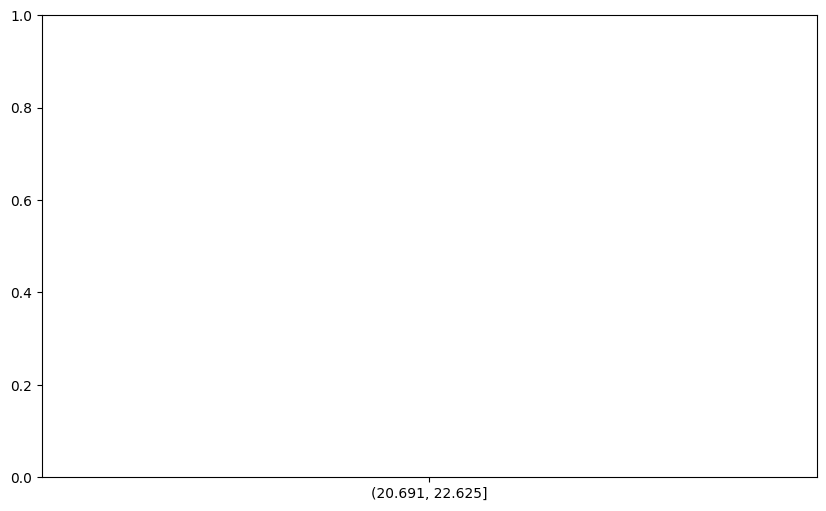

In [ ]:
import json
import matplotlib.pyplot as plt
import pandas as pd

# Caminho do arquivo JSON
json_path = file_name

# Carregar o arquivo JSON
with open(json_path, "r", encoding="utf-8") as f:
    legends = json.load(f)

# Get the legend for the specific variable
col_name = "DS_IMC_PRE_GESTACIONAL"
if col_name in legends:
    legend = legends[col_name]

    imc_values = []
    for cat, val in legend.items():
        if cat.lower() != 'nan':
            try:
                # Ensure 'frequency' exists and is a number
                if isinstance(val, dict) and 'frequency' in val:
                    freq = int(val['frequency'])
                    # Add the category value `freq` times
                    imc_values.extend([float(cat)] * freq)
            except ValueError:
                # Handle cases where conversion to float fails
                pass

    if imc_values:
        # Create categories based on quartiles
        imc_series = pd.Series(imc_values)
        # Use pd.cut with auto bins to get more descriptive bin edges
        try:
            categories = pd.cut(imc_series, bins=4, labels=False, include_lowest=True, duplicates='drop')

            # Count frequencies for each category
            category_counts = categories.value_counts().sort_index()

            # Define category labels based on the bins from pd.cut
            bin_edges = pd.cut(imc_series, bins=4, include_lowest=True, duplicates='drop').cat.categories
            category_labels = [str(interval) for interval in bin_edges]


            # Plotting
            plt.figure(figsize=(10, 6))
            plt.bar(category_labels, category_counts.values, color="skyblue", edgecolor="black")
            plt.title(f"Frequência das categorias de IMC Pré-Gestacional")
            plt.ylabel("Frequência")
            plt.xlabel("Categorias de IMC")
            plt.xticks(rotation=45, ha="right")
            plt.tight_layout()

            # Save image
            output_file = f"{col_name.replace(' ', '_')}_categorizado_frequencia.png"
            plt.savefig(output_file, dpi=300)
            plt.close()
            print(f"✅ Gráfico salvo: {output_file}")
        except ValueError as e:
            print(f"❌ Could not categorize data for {col_name}: {e}")

    else:
        print(f"❌ Não há dados válidos para plotar para {col_name}")
else:
    print(f"❌ A variável '{col_name}' não foi encontrada no arquivo JSON.")